# Multi-Site Energy Yield Assessment — SolarFarmer SDK Workflow 2
**Solcast TMY weather → SolarFarmer `PVSystem` (Workflow 2) → per-site performance metrics**

*Webinar · June 2026 · DNV Green Data Products API*

---

This notebook demonstrates **Workflow 2** of the SolarFarmer SDK: designing plants from
high-level inputs using the `PVSystem` class.  We evaluate a **portfolio of 5 US sites**
(3 × California, 1 × Portland, 1 × Seattle) with a mix of tracker and fixed-tilt
configurations and different AC / DC / grid-connection sizes.

| Step | What happens |
|------|--------------|
| 1 | Load site portfolio from CSV (pandas) |
| 2 | Fetch Solcast TMY weather for all sites **in parallel** |
| 3 | Build a `PVSystem` per site from the DataFrame row |
| 4 | Run SolarFarmer energy calculations **in parallel** |
| 5 | Compare performance metrics across the portfolio |

**Prerequisites:** API keys for [SolarFarmer](https://solarfarmer.dnv.com/) and
[Solcast](https://toolkit.solcast.com.au/register), plus the PAN / OND equipment files
from the `../PVPMC2026/equipment/` folder.

> **Caching:** TMY files are written to `weather/` on first run — subsequent runs skip the Solcast fetch.


## 1. Setup & Configuration

### Environment setup (run once in a terminal)

Requires **Python 3.11+**. All dependencies are listed in `pyproject.toml`.

```bash
cd "WebinarJune2026"
python -m venv .venv
.venv\Scripts\activate      # Windows — use: source .venv/bin/activate on macOS/Linux
pip install .
```

Then select the `.venv` kernel in your IDE before running cells.

In [1]:
import os
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import solarfarmer as sf
from solarfarmer import PVSystem

sf.configure_logging()

# ---------------------------------------------------------------------------
# API keys — set as environment variables or paste here for quick testing
# ---------------------------------------------------------------------------
SF_API_KEY      = os.environ.get("SF_API_KEY",      "YOUR_SF_KEY_HERE")
SOLCAST_API_KEY = os.environ.get("SOLCAST_API_KEY", "YOUR_SOLCAST_KEY_HERE")

for name, key in [("SF_API_KEY", SF_API_KEY), ("SOLCAST_API_KEY", SOLCAST_API_KEY)]:
    status = "found" if "YOUR" not in key else "NOT SET — paste it above or export the env var"
    print(f"{name}: {status}")

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
HERE         = Path(".")
WEATHER_DIR  = HERE / "weather"
WEATHER_DIR.mkdir(exist_ok=True)

# Equipment files — reuse the same PAN/OND from the PVPMC2026 examples
PAN_FILE = Path("../PVPMC2026/equipment/TrinaSolar_TSM-375DE14A(II)_APP.PAN")
OND_FILE = Path("../PVPMC2026/equipment/60_10_APP02.OND")

print(f"\nPAN file exists: {PAN_FILE.exists()}")
print(f"OND file exists: {OND_FILE.exists()}")


SF_API_KEY: found
SOLCAST_API_KEY: found

PAN file exists: True
OND file exists: True


## 2. Site Portfolio — Load from CSV

The file `sites.csv` defines five plants across the US West Coast with a mix of
tracker and fixed-tilt configurations, and different AC / DC / grid capacities.

In [2]:
sites = pd.read_csv(HERE / "sites.csv")

# Pretty-print key columns
display_cols = [
    "site_id", "site_name", "latitude", "longitude", "altitude",
    "mounting", "tilt", "gcr",
    "dc_capacity_MW", "ac_capacity_MW", "grid_limit_MW",
    "bifacial", "inverter_type",
]
print(f"Portfolio: {len(sites)} sites\n")
sites[display_cols].style.set_caption("Site Portfolio")


Portfolio: 5 sites



,site_id,site_name,latitude,longitude,altitude,mounting,tilt,gcr,dc_capacity_MW,ac_capacity_MW,grid_limit_MW,bifacial,inverter_type
0,CA-01,Los Angeles Solar,34.050000,-118.250000,71,Fixed,20.000000,0.400000,12.000000,10.000000,10.500000,True,Central
1,CA-02,San Diego Solar,32.720000,-117.150000,20,Tracker,35.000000,0.350000,20.000000,17.000000,18.000000,True,String
2,CA-03,Sacramento Solar,38.580000,-121.490000,7,Tracker,40.000000,0.420000,15.000000,12.500000,13.000000,True,Central
3,OR-01,Portland Solar,45.520000,-122.680000,15,Fixed,30.000000,0.450000,8.000000,6.500000,7.000000,False,String
4,WA-01,Seattle Solar,47.610000,-122.330000,56,Fixed,35.000000,0.450000,5.000000,4.000000,4.500000,False,String


## 3. Fetch Solcast TMY Weather Data (Multithreaded)

One TMY request per site, issued **in parallel**.
Results are cached to `weather/<site_id>_tmy.csv` — subsequent runs skip the API call.

> Each Solcast TMY call costs 1 free-tier API credit.

In [3]:
%%time
from solcast import tmy

SOLCAST_PARAMS = [
    "ghi", "dhi", "air_temp", "wind_speed_10m",
    "precipitable_water", "precipitation_rate",
]

# Map site_id → weather TSV path (SolarFarmer-ready)
tmy_tsv: dict[str, Path] = {}


def fetch_tmy_for_site(row: pd.Series) -> tuple[str, Path]:
    """Fetch (or load cached) Solcast TMY and write SolarFarmer TSV. Returns (site_id, tsv_path)."""
    site_id  = row["site_id"]
    csv_path = WEATHER_DIR / f"{site_id}_tmy.csv"
    tsv_path = WEATHER_DIR / f"{site_id}_tmy.tsv"

    # --- Fetch or load ---
    if not csv_path.exists():
        df = tmy.radiation_and_weather(
            latitude=row["latitude"],
            longitude=row["longitude"],
            output_parameters=SOLCAST_PARAMS,
            ghi_weight=1.0, # give GHI full weight (commonly known as "typical GHI year" or TGY)
            dni_weight=0.0,
            api_key=SOLCAST_API_KEY,
        ).to_pandas()
        df.to_csv(csv_path)
        print(f"  {site_id}: fetched {len(df)} records → {csv_path.name}")
    else:
        df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
        print(f"  {site_id}: loaded from cache ({len(df)} records)")

    # --- Convert to SolarFarmer TSV ---
    sf.from_solcast(df=df, output_path=tsv_path)
    return site_id, tsv_path


print("Fetching / loading TMY weather for all sites...")
with ThreadPoolExecutor(max_workers=5) as pool:
    futures = {pool.submit(fetch_tmy_for_site, row): row["site_id"]
               for _, row in sites.iterrows()}
    for future in as_completed(futures):
        sid, path = future.result()
        tmy_tsv[sid] = path

print(f"\nAll {len(tmy_tsv)} TMY files ready in {WEATHER_DIR}/")


Fetching / loading TMY weather for all sites...
  OR-01: fetched 8760 records → OR-01_tmy.csv
  CA-02: fetched 8760 records → CA-02_tmy.csv
  CA-03: fetched 8760 records → CA-03_tmy.csv
  WA-01: fetched 8760 records → WA-01_tmy.csv
  CA-01: fetched 8760 records → CA-01_tmy.csv

All 5 TMY files ready in weather/
CPU times: total: 578 ms
Wall time: 11 s


## 4. Build PVSystem Objects from DataFrame

For each row in `sites`, we instantiate a `PVSystem` following **Workflow 2** and
populate all attributes directly from the CSV columns.  The same PAN / OND equipment
files are used for every site so that differences in yield are location- and
design-driven rather than equipment-driven.

In [4]:
def build_pvsystem(row: pd.Series) -> PVSystem:
    """Instantiate and configure a PVSystem from a DataFrame row (Workflow 2)."""
    site_id = row["site_id"]

    plant = PVSystem(
        name=row["site_name"],
        latitude=float(row["latitude"]),
        longitude=float(row["longitude"]),
        altitude=float(row["altitude"]),
        timezone=row["timezone"],
    )

    # --- Capacity ---
    plant.dc_capacity_MW = float(row["dc_capacity_MW"])
    plant.ac_capacity_MW = float(row["ac_capacity_MW"])
    plant.grid_limit_MW  = float(row["grid_limit_MW"])

    # --- Mounting & orientation ---
    mounting_str = str(row["mounting"]).strip().upper()
    plant.mounting = (
        sf.MountingType.TRACKER
        if mounting_str == "TRACKER"
        else sf.MountingType.FIXED
    )
    plant.tilt    = float(row["tilt"])
    plant.azimuth = float(row["azimuth"])
    plant.gcr     = float(row["gcr"])

    # --- Module / electrical ---
    plant.bifacial = str(row["bifacial"]).strip().upper() == "TRUE"

    inverter_str = str(row["inverter_type"]).strip().upper()
    plant.inverter_type = (
        sf.InverterType.STRING
        if inverter_str == "STRING"
        else sf.InverterType.CENTRAL
    )
    plant.transformer_stages = 1

    # --- Equipment ---
    plant.add_pan_files({"Module": PAN_FILE})
    plant.add_ond_files({"Inverter": OND_FILE})

    # --- Weather ---
    plant.weather_file = tmy_tsv[site_id]

    # Suppress per-plant design summary in output
    plant.print_design_summary = False

    return plant


# Build all systems (fast — no API calls here)
pvsystems: dict[str, PVSystem] = {}
for _, row in sites.iterrows():
    pvsystems[row["site_id"]] = build_pvsystem(row)
    print(f"  {row['site_id']:6s}  {row['site_name']:<24s}  "
          f"{row['dc_capacity_MW']:.1f} MWdc / {row['ac_capacity_MW']:.1f} MWac  "
          f"mounting={row['mounting']}")

print(f"\n{len(pvsystems)} PVSystem objects ready.")


  CA-01   Los Angeles Solar         12.0 MWdc / 10.0 MWac  mounting=Fixed
  CA-02   San Diego Solar           20.0 MWdc / 17.0 MWac  mounting=Tracker
  CA-03   Sacramento Solar          15.0 MWdc / 12.5 MWac  mounting=Tracker
  OR-01   Portland Solar            8.0 MWdc / 6.5 MWac  mounting=Fixed
  WA-01   Seattle Solar             5.0 MWdc / 4.0 MWac  mounting=Fixed

5 PVSystem objects ready.


## 5. Run Energy Calculations (Multithreaded)

All five SolarFarmer API calls are dispatched **in parallel** using
`ThreadPoolExecutor`.  Each call runs the full 2D energy simulation for its
site's TMY weather file.

In [5]:
%%time
SF_MAX_WORKERS = 5   # one worker per site — adjust if rate-limited

MONTH_LABELS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]


def run_site(site_id: str, plant: PVSystem) -> dict:
    """Run SolarFarmer energy calculation for one site and collect key metrics."""
    site_name = plant.name
    variant = plant.make_copy()
    variant.name = site_name  # ensure name is set for results labeling
    variant.run_energy_calculation(
        project_id=f"webinar-{site_id.lower()}",
        api_key=SF_API_KEY,
        print_summary=False,
        save_outputs=False,
    )

    perf = variant.results.get_performance(project_year=1)

    # Monthly net energy
    monthly_raw = variant.results.get_monthly_results_table(
        include_energy_results=True, include_effects=False
    )
    monthly_df  = pd.DataFrame(monthly_raw["energy_results"])
    monthly_y1  = monthly_df[monthly_df["project_year"] == 1].sort_values("month")
    monthly_kwh = {
        f"month_{int(m):02d}": e
        for m, e in zip(monthly_y1["month"], monthly_y1["net_energy"])
    }

    row = {
        "site_id":          site_id,
        "site_name":        variant.name,
        "net_energy_MWh":   perf["net_energy"],
        "energy_yield_kWh_per_kWp": perf["energy_yield"],
        "performance_ratio": perf["performance_ratio"],
        "ghi_kWh_m2":       perf["horizontal_irradiation"],
        "dc_capacity_MW":   variant.dc_capacity_MW,
        "ac_capacity_MW":   variant.ac_capacity_MW,
        **monthly_kwh,
    }
    return row


print(f"Running {len(pvsystems)} SolarFarmer calculations with {SF_MAX_WORKERS} workers...")

all_results: list[dict] = []
with ThreadPoolExecutor(max_workers=SF_MAX_WORKERS) as pool:
    futures = {
        pool.submit(run_site, sid, plant): sid
        for sid, plant in pvsystems.items()
    }
    for future in as_completed(futures):
        row = future.result()
        all_results.append(row)
        print(f"{row['site_id']:6s}  {row['site_name']:<24s}  "
              f"{row['net_energy_MWh']:.1f} MWh  |  "
              f"{row['energy_yield_kWh_per_kWp']:.0f} kWh/kWp  |  "
              f"PR={row['performance_ratio']:.3f}")

# Sort by site_id to match the CSV order
all_results.sort(key=lambda r: r["site_id"])
results_df = pd.DataFrame(all_results)

print(f"\nAll {len(results_df)} calculations complete.")


INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 28-05-2026 14:25:30
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 28-05-2026 14:25:30
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 28-05-2026 14:25:30
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 28-05-2026 14:25:30
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 28-05-2026 14:25:30


Running 5 SolarFarmer calculations with 5 workers...


INFO: SUCCESS: Calculation returned successfully (time taken: 7.7 seconds)
INFO: SUCCESS: Calculation returned successfully (time taken: 7.8 seconds)
INFO: SUCCESS: Calculation returned successfully (time taken: 7.9 seconds)


CA-02   San Diego Solar           42404.2 MWh  |  2121 kWh/kWp  |  PR=0.841
CA-03   Sacramento Solar          30265.1 MWh  |  2018 kWh/kWp  |  PR=0.795
WA-01   Seattle Solar             6067.8 MWh  |  1215 kWh/kWp  |  PR=0.776


INFO: SUCCESS: Calculation returned successfully (time taken: 8.9 seconds)
INFO: SUCCESS: Calculation returned successfully (time taken: 9.1 seconds)


CA-01   Los Angeles Solar         21638.0 MWh  |  1803 kWh/kWp  |  PR=0.802
OR-01   Portland Solar            10341.2 MWh  |  1293 kWh/kWp  |  PR=0.802

All 5 calculations complete.
CPU times: total: 1 s
Wall time: 9.31 s


## 6. Performance Metrics — Summary Table

In [6]:
summary_cols = [
    "site_id", "site_name",
    "dc_capacity_MW", "ac_capacity_MW",
    "ghi_kWh_m2", "net_energy_MWh",
    "energy_yield_kWh_per_kWp", "performance_ratio",
]
summary = results_df[summary_cols].copy()

# Merge mounting type from the sites CSV for context
summary = summary.merge(
    sites[["site_id", "mounting"]].rename(columns={"mounting": "Mounting"}),
    on="site_id",
)

summary = summary.rename(columns={
    "site_id":                   "Site ID",
    "site_name":                 "Site Name",
    "dc_capacity_MW":            "DC (MW)",
    "ac_capacity_MW":            "AC (MW)",
    "ghi_kWh_m2":                "GHI (kWh/m²)",
    "net_energy_MWh":            "Net Energy (MWh)",
    "energy_yield_kWh_per_kWp":  "Yield (kWh/kWp)",
    "performance_ratio":         "PR",
})

summary.style \
    .format({
        "DC (MW)": "{:.1f}",
        "AC (MW)": "{:.1f}",
        "GHI (kWh/m²)": "{:.0f}",
        "Net Energy (MWh)": "{:,.0f}",
        "Yield (kWh/kWp)": "{:.0f}",
        "PR": "{:.3f}",
    }) \
    .background_gradient(subset=["Net Energy (MWh)", "Yield (kWh/kWp)", "PR"], cmap="YlGn") \
    .set_caption("Portfolio Performance Summary — Solcast TMY")


,Site ID,Site Name,DC (MW),AC (MW),GHI (kWh/m²),Net Energy (MWh),Yield (kWh/kWp),PR,Mounting
0,CA-01,Los Angeles Solar,12.0,10.0,1990,"21,638",1803,0.802,Fixed
1,CA-02,San Diego Solar,20.0,17.0,1965,"42,404",2121,0.841,Tracker
2,CA-03,Sacramento Solar,15.0,12.5,1914,"30,265",2018,0.795,Tracker
3,OR-01,Portland Solar,8.0,6.5,1398,"10,341",1293,0.802,Fixed
4,WA-01,Seattle Solar,5.0,4.0,1325,"6,068",1215,0.776,Fixed


## 7. Visualise Performance Metrics

Three bar charts side-by-side: **annual net energy**, **specific yield**, and
**performance ratio**, coloured by mounting type.

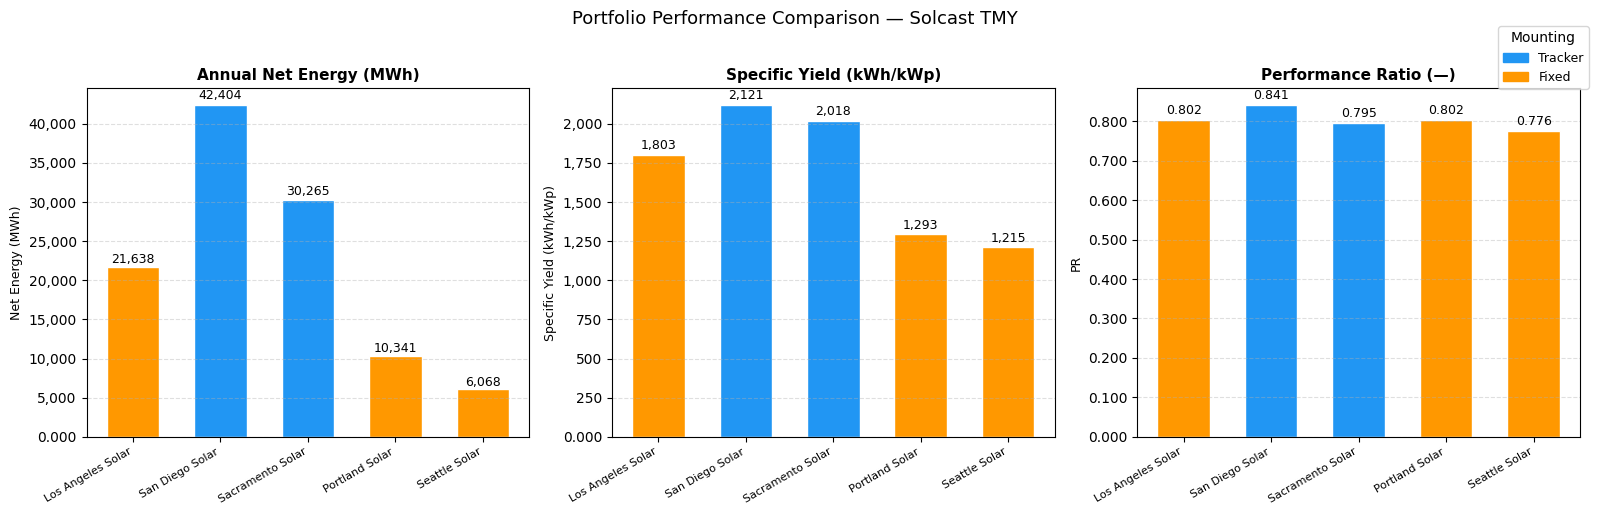

In [7]:
MOUNTING_COLORS = {"Tracker": "#2196F3", "Fixed": "#FF9800"}

labels   = results_df["site_name"].tolist()
site_ids = results_df["site_id"].tolist()
mountings = sites.set_index("site_id").loc[site_ids, "mounting"].tolist()
colors    = [MOUNTING_COLORS.get(m, "#888") for m in mountings]

metrics = [
    ("net_energy_MWh",           "Annual Net Energy (MWh)",        "Net Energy (MWh)"),
    ("energy_yield_kWh_per_kWp", "Specific Yield (kWh/kWp)",       "Specific Yield (kWh/kWp)"),
    ("performance_ratio",        "Performance Ratio (—)",           "PR"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, title, ylabel) in zip(axes, metrics):
    values = results_df[col].tolist()
    bars   = ax.bar(labels, values, color=colors, width=0.6, edgecolor="white")

    # Value labels on bars
    for bar, val in zip(bars, values):
        fmt = f"{val:,.0f}" if val > 10 else f"{val:.3f}"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            fmt,
            ha="center", va="bottom", fontsize=9,
        )

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:,.0f}" if x >= 10 else f"{x:.3f}")
    )
    ax.grid(axis="y", linestyle="--", alpha=0.4)

# Legend
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=c, label=m)
    for m, c in MOUNTING_COLORS.items()
]
fig.legend(handles=legend_handles, title="Mounting", loc="upper right",
           bbox_to_anchor=(1.0, 1.0), fontsize=9)

fig.suptitle("Portfolio Performance Comparison — Solcast TMY", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 8. Monthly Energy Profile

Monthly net energy per site — useful to spot seasonal patterns across climates.

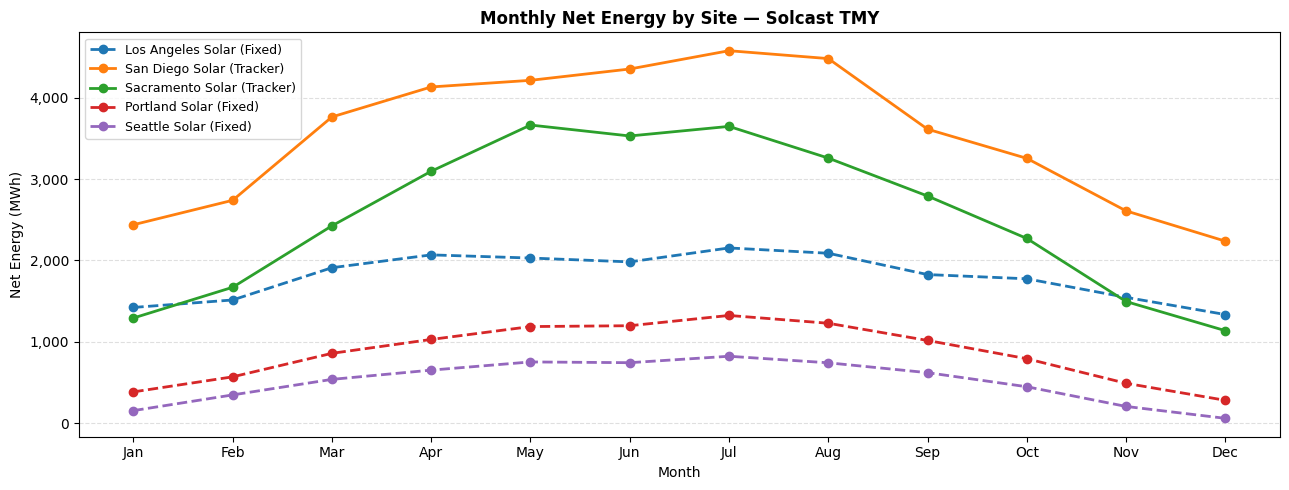

In [8]:
month_cols = [f"month_{m:02d}" for m in range(1, 13)]

fig, ax = plt.subplots(figsize=(13, 5))

for _, row in results_df.iterrows():
    monthly_vals = [row[c] for c in month_cols]
    m_type = sites.loc[sites["site_id"] == row["site_id"], "mounting"].values[0]
    linestyle = "-" if m_type == "Tracker" else "--"
    ax.plot(
        MONTH_LABELS, monthly_vals,
        marker="o", linewidth=2, linestyle=linestyle,
        label=f"{row['site_name']} ({m_type})",
    )

ax.set_title("Monthly Net Energy by Site — Solcast TMY", fontsize=12, fontweight="bold")
ax.set_ylabel("Net Energy (MWh)")
ax.set_xlabel("Month")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()


## 9. Normalised Yield — kWh per Installed MW

To compare sites with different capacities on equal footing, express energy as
**specific yield** (kWh per kWp installed DC) alongside the raw site output.

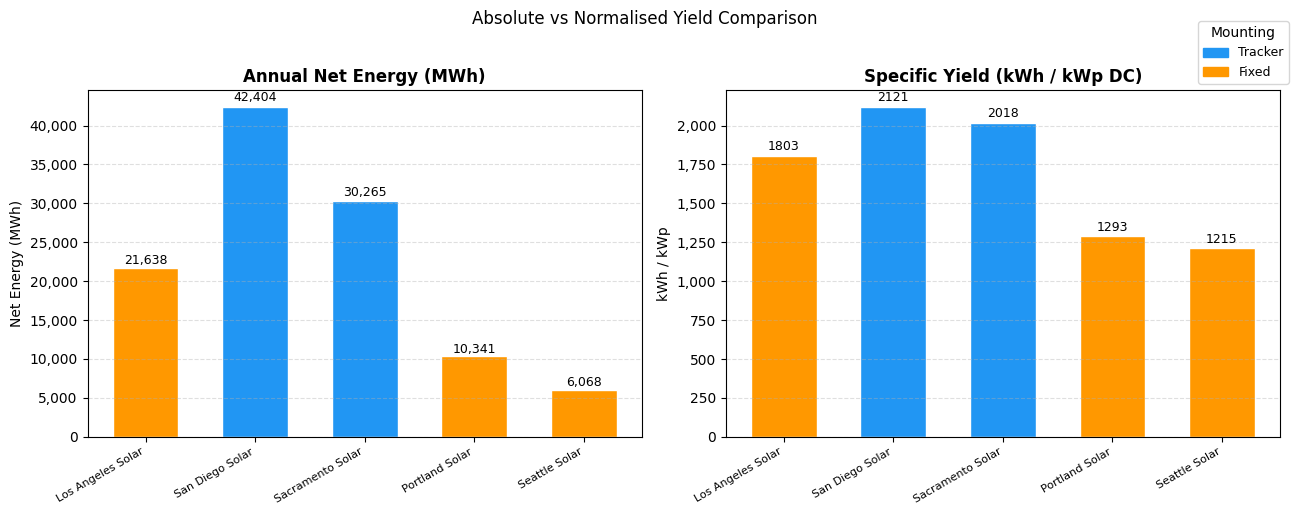

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: Gross energy (total MWh) ---
ax = axes[0]
vals = results_df["net_energy_MWh"].tolist()
bars = ax.bar(labels, vals, color=colors, width=0.6, edgecolor="white")
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
            f"{val:,.0f}", ha="center", va="bottom", fontsize=9)
ax.set_title("Annual Net Energy (MWh)", fontweight="bold")
ax.set_ylabel("Net Energy (MWh)")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.grid(axis="y", linestyle="--", alpha=0.4)

# --- Right: Specific yield (kWh/kWp) ---
ax = axes[1]
vals = results_df["energy_yield_kWh_per_kWp"].tolist()
bars = ax.bar(labels, vals, color=colors, width=0.6, edgecolor="white")
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
            f"{val:.0f}", ha="center", va="bottom", fontsize=9)
ax.set_title("Specific Yield (kWh / kWp DC)", fontweight="bold")
ax.set_ylabel("kWh / kWp")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Shared legend
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=c, label=m)
    for m, c in MOUNTING_COLORS.items()
]
fig.legend(handles=legend_handles, title="Mounting", loc="upper right",
           bbox_to_anchor=(1.0, 1.01), fontsize=9)

fig.suptitle("Absolute vs Normalised Yield Comparison", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 10. Summary

You have completed a multi-site energy yield assessment combining Solcast satellite
weather data with SolarFarmer Workflow 2 bankable energy calculations:

| Step | Tool / Method |
|------|---------------|
| Load site portfolio | `pd.read_csv("sites.csv")` — 5 US West Coast sites |
| Fetch TMY weather (parallel) | `solcast.tmy.radiation_and_weather()` via `ThreadPoolExecutor` |
| Cache weather to disk | `weather/<site_id>_tmy.csv` — skipped on re-runs |
| Design plants | `PVSystem(...)` — Workflow 2 from DataFrame rows |
| Run calculations (parallel) | `plant.run_energy_calculation()` × 5 via `ThreadPoolExecutor` |
| Collect results | `results_df` — net energy, specific yield, PR, monthly profile |
| Visualise | Bar charts, monthly profiles, absolute vs. normalised yield |

### Key observations
- **Tracker vs. fixed-tilt** — single-axis trackers consistently produce higher
  specific yield (kWh/kWp) than fixed-tilt arrays at the same location, with the
  gain varying by latitude and seasonal irradiance distribution.
- **Climate gradient** — California sites outperform the Pacific Northwest sites on
  annual GHI and net energy; the yield gap widens in winter months when Seattle
  and Portland are cloud-dominated.
- **Absolute vs. normalised yield** — ranking sites by raw MWh favours larger
  plants; specific yield (kWh/kWp DC) and performance ratio provide a
  design-quality metric that is independent of installed capacity.
- **Performance ratio** — differences in PR across sites reflect a combination of
  irradiance climate, inverter clipping (DC/AC ratio), and mounting-type gain.
- **Parallel API calls** — dispatching all Solcast TMY fetches and SolarFarmer
  simulations concurrently with `ThreadPoolExecutor` reduces total wall-clock
  time from O(N × t) to roughly O(t), with minimal code complexity.

---
**Next steps:**
- Extend to historic or P50/P90 weather to add inter-annual variability analysis
  (see `PVPMC2026/05_solcast_solarfarmer_multiyear.ipynb`)
- Add soiling losses using `pvlib.soiling.kimber()` driven by site-specific
  precipitation data from the Solcast response
- Incorporate degradation curves and OPEX assumptions to build a full LCOE model

**Documentation & support:**
- SolarFarmer SDK: https://dnv-opensource.github.io/solarfarmer-python-sdk/
- Solcast SDK: https://solcast.github.io/solcast-api-python-sdk/

*Thank you for joining our webinar!*
